<a href="https://colab.research.google.com/github/FaridRash/brain-ct-hemorrhage-segmentation/blob/main/Notebooks/conversion_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Git Clone

In [1]:
!git clone https://github.com/FaridRash/brain-ct-hemorrhage-segmentation
%cd brain-ct-hemorrhage-segmentation/Notebooks

Cloning into 'brain-ct-hemorrhage-segmentation'...
remote: Enumerating objects: 246, done.
remote: Counting objects: 100% (77/77), done.
remote: Compressing objects: 100% (74/74), done.
remote: Total 246 (delta 18), reused 11 (delta 1), pack-reused 169 (from 2)
Receiving objects: 100% (246/246), 572.78 MiB | 16.54 MiB/s, done.
Resolving deltas: 100% (82/82), done.
Updating files: 100% (161/161), done.
/content/brain-ct-hemorrhage-segmentation/Notebooks


#Data Integrity Check

In [2]:
import os
import nibabel as nib

ct_path = "/content/brain-ct-hemorrhage-segmentation/Data/computed-tomography-images-for-intracranial-hemorrhage-detection-and-segmentation-1.3.1/ct_scans"
mask_path = "/content/brain-ct-hemorrhage-segmentation/Data/computed-tomography-images-for-intracranial-hemorrhage-detection-and-segmentation-1.3.1/masks"

# get one sample file
ct_file = sorted(os.listdir(ct_path))[0]
mask_file = sorted(os.listdir(mask_path))[0]

print("CT file:", ct_file)
print("Mask file:", mask_file)

# load
ct_img = nib.load(os.path.join(ct_path, ct_file))
mask_img = nib.load(os.path.join(mask_path, mask_file))

# convert to numpy
ct_data = ct_img.get_fdata()
mask_data = mask_img.get_fdata()

# print info
print("\nCT shape:", ct_data.shape)
print("Mask shape:", mask_data.shape)

print("\nCT dtype:", ct_data.dtype)
print("Mask dtype:", mask_data.dtype)

print("\nCT spacing:", ct_img.header.get_zooms())
print("Mask spacing:", mask_img.header.get_zooms())

CT file: 049.nii
Mask file: 049.nii

CT shape: (512, 512, 39)
Mask shape: (512, 512, 39)

CT dtype: float64
Mask dtype: float64

CT spacing: (np.float32(0.41210938), np.float32(0.41210938), np.float32(5.0))
Mask spacing: (np.float32(0.41210938), np.float32(0.41210938), np.float32(5.0))


Shape: (512, 512, 39) → standard axial CT (39 slices)

Spacing:

x,y ≈ 0.41 mm (high resolution)

z = 5.0 mm (thick slices → low resolution in depth)

In [3]:
import nibabel as nib

print("CT orientation:", nib.aff2axcodes(ct_img.affine))
print("Mask orientation:", nib.aff2axcodes(mask_img.affine))

CT orientation: ('L', 'A', 'S')
Mask orientation: ('L', 'A', 'S')


Same orientation

No flipping issue

**The CT and mask are pixel-wise aligned**

#Visual Alignment Check

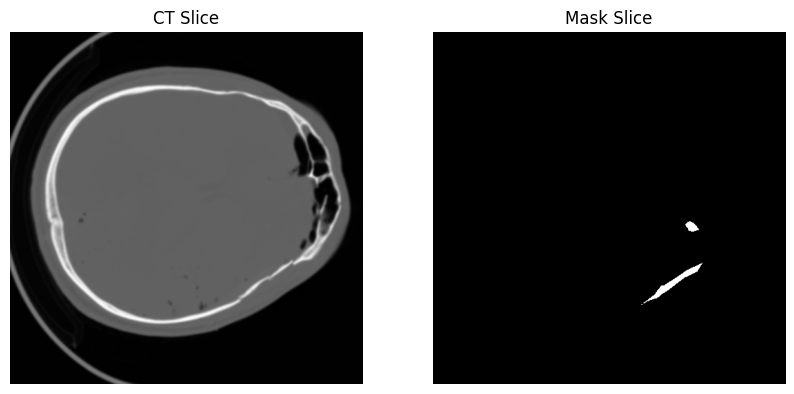

In [4]:
import matplotlib.pyplot as plt

slice_idx = 20  # middle slice

plt.figure(figsize=(10,5))

# CT image
plt.subplot(1,2,1)
plt.imshow(ct_data[:, :, slice_idx], cmap='gray')
plt.title("CT Slice")
plt.axis("off")

# Mask
plt.subplot(1,2,2)
plt.imshow(mask_data[:, :, slice_idx], cmap='gray')
plt.title("Mask Slice")
plt.axis("off")

plt.show()

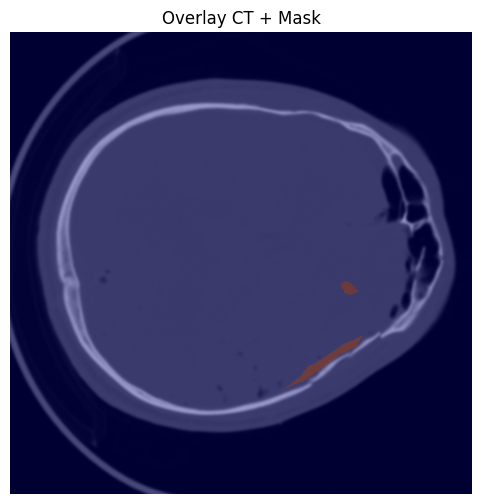

In [5]:
plt.figure(figsize=(6,6))
plt.imshow(ct_data[:, :, slice_idx], cmap='gray')
plt.imshow(mask_data[:, :, slice_idx], cmap='jet', alpha=0.4)
plt.title("Overlay CT + Mask")
plt.axis("off")
plt.show()

In [6]:
import numpy as np

print("Unique mask values:", np.unique(mask_data))

Unique mask values: [  0.         254.99999994]


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

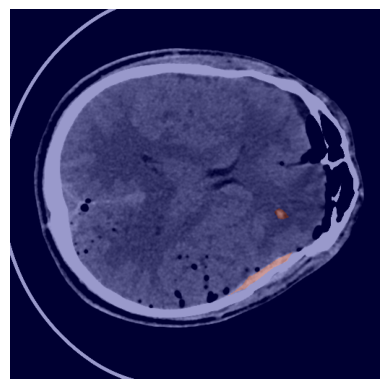

In [7]:
def window_ct(img, level=40, width=80):
    min_val = level - width // 2
    max_val = level + width // 2
    img = np.clip(img, min_val, max_val)
    img = (img - min_val) / (max_val - min_val)
    return img

ct_windowed = window_ct(ct_data[:, :, 20])

plt.imshow(ct_windowed, cmap='gray')
plt.imshow(mask_data[:, :, 20], cmap='jet', alpha=0.4)
plt.axis("off")

In [8]:
ct_slice = ct_data[:, :, 20]
mask_slice = mask_data[:, :, 20]

masked_pixels = ct_slice[mask_slice > 0]

print("Mean intensity inside mask:", masked_pixels.mean())
print("Mean intensity outside mask:", ct_slice[mask_slice == 0].mean())

Mean intensity inside mask: 68.92247191011236
Mean intensity outside mask: -380.0355209872385


#Train

In [9]:
import pandas as pd

# choose which split you want
split_path = "/content/drive/MyDrive/brain_ct_project/splits/train_scans.csv"

df_split = pd.read_csv(split_path)

scan_list = df_split["scan_id"].values

print("Number of scans in this split:", len(scan_list))
print("First 5 scan IDs:", scan_list[:5])

Number of scans in this split: 60
First 5 scan IDs: [ 71  81 108 127  79]


In [10]:
pairs = []

for scan_id in scan_list:

    scan_id = str(scan_id)

    ct_file = scan_id + ".nii"
    mask_file = scan_id + ".nii"

    ct_full_path = os.path.join(ct_path, ct_file)
    mask_full_path = os.path.join(mask_path, mask_file)

    if os.path.exists(ct_full_path) and os.path.exists(mask_full_path):
        pairs.append((ct_file, mask_file))
    else:
        print(f"WARNING: Missing file for scan {scan_id}")

print("Total matched pairs:", len(pairs))

Total matched pairs: 24


In [11]:
import os

# paths (keep consistent with your notebook)
ct_path = "/content/brain-ct-hemorrhage-segmentation/Data/computed-tomography-images-for-intracranial-hemorrhage-detection-and-segmentation-1.3.1/ct_scans"
mask_path = "/content/brain-ct-hemorrhage-segmentation/Data/computed-tomography-images-for-intracranial-hemorrhage-detection-and-segmentation-1.3.1/masks"

pairs = []

for scan_id in scan_list:

    # ensure string format
    scan_id = str(scan_id)

    ct_file = scan_id + ".nii"
    mask_file = scan_id + ".nii"

    ct_full_path = os.path.join(ct_path, ct_file)
    mask_full_path = os.path.join(mask_path, mask_file)

    if os.path.exists(ct_full_path) and os.path.exists(mask_full_path):
        pairs.append((ct_file, mask_file))
    else:
        print(f"WARNING: Missing file for scan {scan_id}")

print("Total matched pairs:", len(pairs))
print("First 5 pairs:", pairs[:5])

Total matched pairs: 24
First 5 pairs: [('108.nii', '108.nii'), ('127.nii', '127.nii'), ('118.nii', '118.nii'), ('105.nii', '105.nii'), ('115.nii', '115.nii')]


In [12]:
image_slices = []
mask_slices = []

for ct_file, mask_file in pairs:

    # full paths
    ct_full_path = os.path.join(ct_path, ct_file)
    mask_full_path = os.path.join(mask_path, mask_file)

    # load volumes
    ct_vol = nib.load(ct_full_path).get_fdata()
    mask_vol = nib.load(mask_full_path).get_fdata()

    # iterate over slices (Z axis)
    for i in range(ct_vol.shape[2]):

        img_slice = ct_vol[:, :, i]
        mask_slice = mask_vol[:, :, i]

        image_slices.append(img_slice)
        mask_slices.append(mask_slice)

print("Total slices:", len(image_slices))

Total slices: 882


In [13]:
import os

base_dir = "/content/processed_data"

# choose split name (change later for val/test)
split_name = "train"

# split directories
split_dir = os.path.join(base_dir, split_name)

img_npy_dir = os.path.join(split_dir, "images")
mask_npy_dir = os.path.join(split_dir, "masks")

# create folders
for d in [img_npy_dir, mask_npy_dir]:
    os.makedirs(d, exist_ok=True)

print("Saving to:", split_dir)

Saving to: /content/processed_data/train


#Val

In [14]:
import pandas as pd

# choose which split you want
split_path = "/content/drive/MyDrive/brain_ct_project/splits/val_scans.csv"

df_split = pd.read_csv(split_path)

scan_list = df_split["scan_id"].values

print("Number of scans in this split:", len(scan_list))
print("First 5 scan IDs:", scan_list[:5])

Number of scans in this split: 7
First 5 scan IDs: [ 87  52 112 102 114]


In [15]:
pairs = []

for scan_id in scan_list:

    scan_id = str(scan_id)

    ct_file = scan_id + ".nii"
    mask_file = scan_id + ".nii"

    ct_full_path = os.path.join(ct_path, ct_file)
    mask_full_path = os.path.join(mask_path, mask_file)

    if os.path.exists(ct_full_path) and os.path.exists(mask_full_path):
        pairs.append((ct_file, mask_file))
    else:
        print(f"WARNING: Missing file for scan {scan_id}")

print("Total matched pairs:", len(pairs))

Total matched pairs: 3


In [16]:
import os

# paths (keep consistent with your notebook)
ct_path = "/content/brain-ct-hemorrhage-segmentation/Data/computed-tomography-images-for-intracranial-hemorrhage-detection-and-segmentation-1.3.1/ct_scans"
mask_path = "/content/brain-ct-hemorrhage-segmentation/Data/computed-tomography-images-for-intracranial-hemorrhage-detection-and-segmentation-1.3.1/masks"

pairs = []

for scan_id in scan_list:

    # ensure string format
    scan_id = str(scan_id)

    ct_file = scan_id + ".nii"
    mask_file = scan_id + ".nii"

    ct_full_path = os.path.join(ct_path, ct_file)
    mask_full_path = os.path.join(mask_path, mask_file)

    if os.path.exists(ct_full_path) and os.path.exists(mask_full_path):
        pairs.append((ct_file, mask_file))
    else:
        print(f"WARNING: Missing file for scan {scan_id}")

print("Total matched pairs:", len(pairs))
print("First 5 pairs:", pairs[:5])

Total matched pairs: 3
First 5 pairs: [('112.nii', '112.nii'), ('102.nii', '102.nii'), ('114.nii', '114.nii')]


In [17]:
image_slices = []
mask_slices = []

for ct_file, mask_file in pairs:

    # full paths
    ct_full_path = os.path.join(ct_path, ct_file)
    mask_full_path = os.path.join(mask_path, mask_file)

    # load volumes
    ct_vol = nib.load(ct_full_path).get_fdata()
    mask_vol = nib.load(mask_full_path).get_fdata()

    # iterate over slices (Z axis)
    for i in range(ct_vol.shape[2]):

        img_slice = ct_vol[:, :, i]
        mask_slice = mask_vol[:, :, i]

        image_slices.append(img_slice)
        mask_slices.append(mask_slice)

print("Total slices:", len(image_slices))

Total slices: 107


In [18]:
import os

base_dir = "/content/processed_data"

# choose split name (change later for val/test)
split_name = "val"

# split directories
split_dir = os.path.join(base_dir, split_name)

img_npy_dir = os.path.join(split_dir, "images")
mask_npy_dir = os.path.join(split_dir, "masks")

# create folders
for d in [img_npy_dir, mask_npy_dir]:
    os.makedirs(d, exist_ok=True)

print("Saving to:", split_dir)

Saving to: /content/processed_data/val


#Test

In [19]:
import pandas as pd

# choose which split you want
split_path = "/content/drive/MyDrive/brain_ct_project/splits/test_scans.csv"

df_split = pd.read_csv(split_path)

scan_list = df_split["scan_id"].values

print("Number of scans in this split:", len(scan_list))
print("First 5 scan IDs:", scan_list[:5])

Number of scans in this split: 8
First 5 scan IDs: [ 84 106 130  77 120]


In [20]:
pairs = []

for scan_id in scan_list:

    scan_id = str(scan_id)

    ct_file = scan_id + ".nii"
    mask_file = scan_id + ".nii"

    ct_full_path = os.path.join(ct_path, ct_file)
    mask_full_path = os.path.join(mask_path, mask_file)

    if os.path.exists(ct_full_path) and os.path.exists(mask_full_path):
        pairs.append((ct_file, mask_file))
    else:
        print(f"WARNING: Missing file for scan {scan_id}")

print("Total matched pairs:", len(pairs))

Total matched pairs: 4


In [21]:
import os

# paths (keep consistent with your notebook)
ct_path = "/content/brain-ct-hemorrhage-segmentation/Data/computed-tomography-images-for-intracranial-hemorrhage-detection-and-segmentation-1.3.1/ct_scans"
mask_path = "/content/brain-ct-hemorrhage-segmentation/Data/computed-tomography-images-for-intracranial-hemorrhage-detection-and-segmentation-1.3.1/masks"

pairs = []

for scan_id in scan_list:

    # ensure string format
    scan_id = str(scan_id)

    ct_file = scan_id + ".nii"
    mask_file = scan_id + ".nii"

    ct_full_path = os.path.join(ct_path, ct_file)
    mask_full_path = os.path.join(mask_path, mask_file)

    if os.path.exists(ct_full_path) and os.path.exists(mask_full_path):
        pairs.append((ct_file, mask_file))
    else:
        print(f"WARNING: Missing file for scan {scan_id}")

print("Total matched pairs:", len(pairs))
print("First 5 pairs:", pairs[:5])

Total matched pairs: 4
First 5 pairs: [('106.nii', '106.nii'), ('130.nii', '130.nii'), ('120.nii', '120.nii'), ('110.nii', '110.nii')]


In [22]:
image_slices = []
mask_slices = []

for ct_file, mask_file in pairs:

    # full paths
    ct_full_path = os.path.join(ct_path, ct_file)
    mask_full_path = os.path.join(mask_path, mask_file)

    # load volumes
    ct_vol = nib.load(ct_full_path).get_fdata()
    mask_vol = nib.load(mask_full_path).get_fdata()

    # iterate over slices (Z axis)
    for i in range(ct_vol.shape[2]):

        img_slice = ct_vol[:, :, i]
        mask_slice = mask_vol[:, :, i]

        image_slices.append(img_slice)
        mask_slices.append(mask_slice)

print("Total slices:", len(image_slices))

Total slices: 140


In [23]:
import os

base_dir = "/content/processed_data"

# choose split name (change later for val/test)
split_name = "test"

# split directories
split_dir = os.path.join(base_dir, split_name)

img_npy_dir = os.path.join(split_dir, "images")
mask_npy_dir = os.path.join(split_dir, "masks")

# create folders
for d in [img_npy_dir, mask_npy_dir]:
    os.makedirs(d, exist_ok=True)

print("Saving to:", split_dir)

Saving to: /content/processed_data/test


#Test the data

In [24]:
import os

for split in ["train", "val", "test"]:
    img_dir = f"/content/processed_data/{split}/images"
    mask_dir = f"/content/processed_data/{split}/masks"

    print(f"\n{split.upper()}")
    print("Images:", len(os.listdir(img_dir)))
    print("Masks :", len(os.listdir(mask_dir)))


TRAIN
Images: 0
Masks : 0

VAL
Images: 0
Masks : 0

TEST
Images: 0
Masks : 0


#Save the files

##Train

In [25]:
import pandas as pd

split_path = "/content/drive/MyDrive/brain_ct_project/splits/train_scans.csv"

df_split = pd.read_csv(split_path)
scan_list = df_split["scan_id"].astype(str).values

print("Using:", split_path)
print("Scans:", len(scan_list))

Using: /content/drive/MyDrive/brain_ct_project/splits/train_scans.csv
Scans: 60


In [26]:
import os

pairs = []

for scan_id in scan_list:
    scan_id = str(scan_id).zfill(3)

    ct_file = scan_id + ".nii"
    mask_file = scan_id + ".nii"

    ct_full = os.path.join(ct_path, ct_file)
    mask_full = os.path.join(mask_path, mask_file)

    if os.path.exists(ct_full) and os.path.exists(mask_full):
        pairs.append((ct_file, mask_file))

print("Pairs:", len(pairs))

Pairs: 60


In [27]:
image_slices = []
mask_slices = []

for ct_file, mask_file in pairs:

    ct_full = os.path.join(ct_path, ct_file)
    mask_full = os.path.join(mask_path, mask_file)

    ct_vol = nib.load(ct_full).get_fdata()
    mask_vol = nib.load(mask_full).get_fdata()

    for i in range(ct_vol.shape[2]):
        image_slices.append(ct_vol[:, :, i])
        mask_slices.append(mask_vol[:, :, i])

print("Slices:", len(image_slices))

Slices: 2281


In [28]:
import shutil

shutil.rmtree("/content/processed_data/train", ignore_errors=True)

In [29]:
base_dir = "/content/processed_data"

img_npy_dir = os.path.join(base_dir, "train", "images")
mask_npy_dir = os.path.join(base_dir, "train", "masks")

os.makedirs(img_npy_dir, exist_ok=True)
os.makedirs(mask_npy_dir, exist_ok=True)

print("Saving to:", img_npy_dir)

Saving to: /content/processed_data/train/images


In [30]:
import numpy as np

print("Saving:", len(image_slices))

for i, (img, mask) in enumerate(zip(image_slices, mask_slices)):

    np.save(os.path.join(img_npy_dir, f"slice_{i:05d}.npy"), img.astype(np.float32))
    np.save(os.path.join(mask_npy_dir, f"slice_{i:05d}.npy"), (mask > 0).astype(np.uint8))

print("TRAIN DONE")

Saving: 2281
TRAIN DONE


In [31]:
import os

print("Images:", len(os.listdir(img_npy_dir)))
print("Masks :", len(os.listdir(mask_npy_dir)))

Images: 2281
Masks : 2281


##Val

In [32]:
import pandas as pd

split_path = "/content/drive/MyDrive/brain_ct_project/splits/val_scans.csv"

df_split = pd.read_csv(split_path)
scan_list = df_split["scan_id"].astype(str).values

print("Using:", split_path)
print("Scans:", len(scan_list))

Using: /content/drive/MyDrive/brain_ct_project/splits/val_scans.csv
Scans: 7


In [33]:
import os

pairs = []

for scan_id in scan_list:
    scan_id = str(scan_id).zfill(3)

    ct_file = scan_id + ".nii"
    mask_file = scan_id + ".nii"

    ct_full = os.path.join(ct_path, ct_file)
    mask_full = os.path.join(mask_path, mask_file)

    if os.path.exists(ct_full) and os.path.exists(mask_full):
        pairs.append((ct_file, mask_file))

print("Pairs:", len(pairs))

Pairs: 7


In [34]:
image_slices = []
mask_slices = []

for ct_file, mask_file in pairs:

    ct_full = os.path.join(ct_path, ct_file)
    mask_full = os.path.join(mask_path, mask_file)

    ct_vol = nib.load(ct_full).get_fdata()
    mask_vol = nib.load(mask_full).get_fdata()

    for i in range(ct_vol.shape[2]):
        image_slices.append(ct_vol[:, :, i])
        mask_slices.append(mask_vol[:, :, i])

print("Slices:", len(image_slices))

Slices: 241


In [35]:
import shutil

shutil.rmtree("/content/processed_data/val", ignore_errors=True)

In [36]:
base_dir = "/content/processed_data"

img_npy_dir = os.path.join(base_dir, "val", "images")
mask_npy_dir = os.path.join(base_dir, "val", "masks")

os.makedirs(img_npy_dir, exist_ok=True)
os.makedirs(mask_npy_dir, exist_ok=True)

print("Saving to:", img_npy_dir)

Saving to: /content/processed_data/val/images


In [37]:
import numpy as np

print("Saving:", len(image_slices))

for i, (img, mask) in enumerate(zip(image_slices, mask_slices)):

    np.save(os.path.join(img_npy_dir, f"slice_{i:05d}.npy"), img.astype(np.float32))
    np.save(os.path.join(mask_npy_dir, f"slice_{i:05d}.npy"), (mask > 0).astype(np.uint8))

print("VAL DONE")

Saving: 241
VAL DONE


In [38]:
import os

print("VAL Images:", len(os.listdir(img_npy_dir)))
print("VAL Masks :", len(os.listdir(mask_npy_dir)))

VAL Images: 241
VAL Masks : 241


##Test

In [39]:
import pandas as pd

split_path = "/content/drive/MyDrive/brain_ct_project/splits/test_scans.csv"

df_split = pd.read_csv(split_path)
scan_list = df_split["scan_id"].astype(str).values

print("Using:", split_path)
print("Scans:", len(scan_list))

Using: /content/drive/MyDrive/brain_ct_project/splits/test_scans.csv
Scans: 8


In [40]:
import os

pairs = []

for scan_id in scan_list:
    scan_id = str(scan_id).zfill(3)

    ct_file = scan_id + ".nii"
    mask_file = scan_id + ".nii"

    ct_full = os.path.join(ct_path, ct_file)
    mask_full = os.path.join(mask_path, mask_file)

    if os.path.exists(ct_full) and os.path.exists(mask_full):
        pairs.append((ct_file, mask_file))

print("Pairs:", len(pairs))

Pairs: 8


In [41]:
image_slices = []
mask_slices = []

for ct_file, mask_file in pairs:

    ct_full = os.path.join(ct_path, ct_file)
    mask_full = os.path.join(mask_path, mask_file)

    ct_vol = nib.load(ct_full).get_fdata()
    mask_vol = nib.load(mask_full).get_fdata()

    for i in range(ct_vol.shape[2]):
        image_slices.append(ct_vol[:, :, i])
        mask_slices.append(mask_vol[:, :, i])

print("Slices:", len(image_slices))

Slices: 292


In [42]:
import shutil

shutil.rmtree("/content/processed_data/test", ignore_errors=True)

In [43]:
base_dir = "/content/processed_data"

img_npy_dir = os.path.join(base_dir, "test", "images")
mask_npy_dir = os.path.join(base_dir, "test", "masks")

os.makedirs(img_npy_dir, exist_ok=True)
os.makedirs(mask_npy_dir, exist_ok=True)

print("Saving to:", img_npy_dir)

Saving to: /content/processed_data/test/images


In [44]:
import numpy as np

print("Saving:", len(image_slices))

for i, (img, mask) in enumerate(zip(image_slices, mask_slices)):

    np.save(os.path.join(img_npy_dir, f"slice_{i:05d}.npy"), img.astype(np.float32))
    np.save(os.path.join(mask_npy_dir, f"slice_{i:05d}.npy"), (mask > 0).astype(np.uint8))

print("TEST DONE")

Saving: 292
TEST DONE


In [45]:
import os

print("TEST Images:", len(os.listdir(img_npy_dir)))
print("TEST Masks :", len(os.listdir(mask_npy_dir)))

TEST Images: 292
TEST Masks : 292


#Test the data

In [46]:
import os

for split in ["train", "val", "test"]:
    path = f"/content/processed_data/{split}/images"
    if os.path.exists(path):
        print(split, len(os.listdir(path)))
    else:
        print(split, "NOT CREATED")

train 2281
val 241
test 292


#Export zipped files to Google.Drive

In [48]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [49]:
import shutil
import os

# source folder
source_dir = "/content/processed_data"

# destination (Drive)
save_dir = "/content/drive/MyDrive/brain_ct_project"
os.makedirs(save_dir, exist_ok=True)

zip_path = os.path.join(save_dir, "processed_data_full.zip")

# create zip
shutil.make_archive(
    base_name=zip_path.replace(".zip", ""),
    format="zip",
    root_dir=source_dir
)

print("ZIP saved to:", zip_path)

ZIP saved to: /content/drive/MyDrive/brain_ct_project/processed_data_full.zip
